In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
#Load processed data
X = np.load('../data/processed/X_windows.npy')
y = np.load('../data/processed/y_labels.npy')
engine_ids = np.load('../data/processed/engine_ids.npy')
rul_targets = np.load('../data/processed/rul_targets.npy')

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Anomaly rate:", y.mean().round(4))

X shape: (17731, 30, 11)
y shape: (17731,)
Anomaly rate: 0.1692


In [4]:
# Will train autoencoder only on normal data
X_normal = X[y == 0]
X_anomaly = X[y == 1]

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

print("Training normal windows:", X_train.shape)
print("Validation normal windows:", X_val.shape)
print("Anomalous windows:", X_anomaly.shape)

Training normal windows: (11784, 30, 11)
Validation normal windows: (2947, 30, 11)
Anomalous windows: (3000, 30, 11)


In [5]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)
latent = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(latent)
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mae')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 11)         │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,195 (207.79 KB)

 Trainable params: 53,195 (207.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1112 - val_loss: 0.0914
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0897 - val_loss: 0.0884
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0873 - val_loss: 0.0871
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0863 - val_loss: 0.0865
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0859 - val_loss: 0.0864
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0856 - val_loss: 0.0857
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0854 - val_loss: 0.0856
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0853 - val_loss: 0.0853
Epoch 9/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0852 - val_loss: 0.0855
Epoch 10/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0852 - val_loss: 0.0856
Epoch 11/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0851 - val_loss: 0.0850
Epoch 12/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 

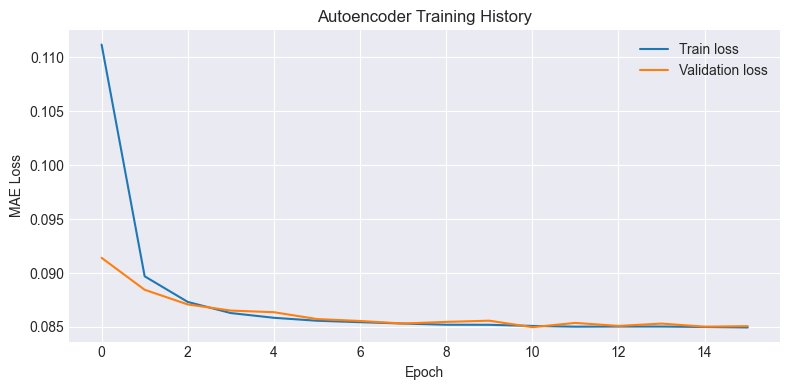

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('Autoencoder Training History')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
X_train_pred = autoencoder.predict(X_train, verbose=0)
X_val_pred = autoencoder.predict(X_val, verbose=0)
X_anomaly_pred = autoencoder.predict(X_anomaly, verbose=0)

train_mae = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))
val_mae = np.mean(np.abs(X_val_pred - X_val), axis=(1, 2))
anomaly_mae = np.mean(np.abs(X_anomaly_pred - X_anomaly), axis=(1, 2))

print("Train MAE mean:", train_mae.mean().round(4))
print("Val MAE mean:", val_mae.mean().round(4))
print("Anomaly MAE mean:", anomaly_mae.mean().round(4))

Train MAE mean: 0.0851
Val MAE mean: 0.085
Anomaly MAE mean: 0.0953


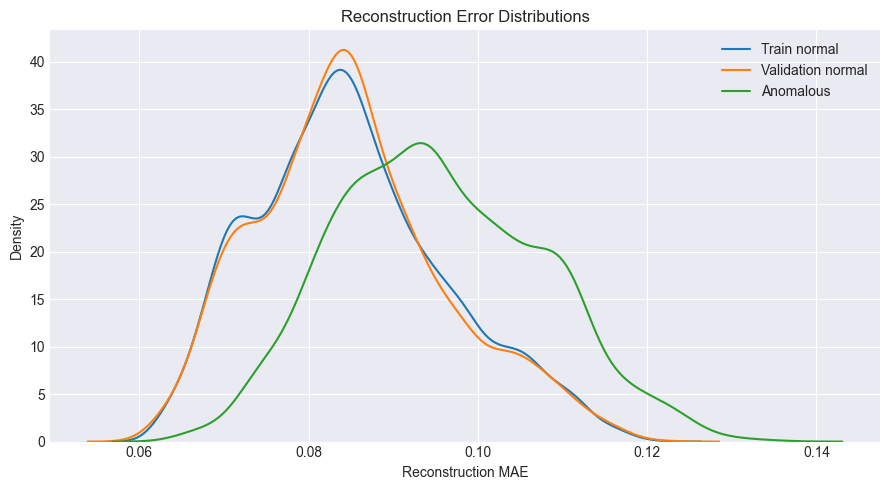

In [9]:
plt.figure(figsize=(9, 5))
sns.kdeplot(train_mae, label='Train normal')
sns.kdeplot(val_mae, label='Validation normal')
sns.kdeplot(anomaly_mae, label='Anomalous')
plt.xlabel('Reconstruction MAE')
plt.ylabel('Density')
plt.title('Reconstruction Error Distributions')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
threshold = np.percentile(val_mae, 95)
print("Threshold:", round(threshold, 4))

Threshold: 0.1064


In [11]:
y_true = np.concatenate([np.zeros_like(val_mae), np.ones_like(anomaly_mae)])
y_scores = np.concatenate([val_mae, anomaly_mae])
y_pred = (y_scores > threshold).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

[[2799  148]
 [2379  621]]
              precision    recall  f1-score   support

      Normal       0.54      0.95      0.69      2947
     Anomaly       0.81      0.21      0.33      3000

    accuracy                           0.58      5947
   macro avg       0.67      0.58      0.51      5947
weighted avg       0.68      0.58      0.51      5947



The threshold looks too conservative. Lets try a few different options.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.percentile(val_mae, [80, 85, 90, 92, 95, 97, 98])

rows = []
for t in thresholds:
    pred = (y_scores > t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_true, pred),
        'recall': recall_score(y_true, pred),
        'f1': f1_score(y_true, pred)
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1
0,0.093714,0.726725,0.523000,0.608257
1,0.096870,0.743917,0.428000,0.543377
2,0.101162,0.763622,0.317667,0.448682
3,0.103179,0.776727,0.273667,0.404733
4,0.106378,0.807542,0.207000,0.329530
5,0.108841,0.842756,0.159000,0.267527
6,0.110655,0.856098,0.117000,0.205865


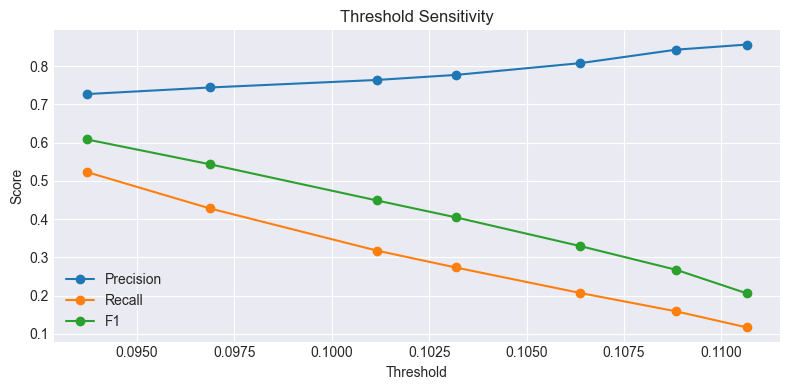

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Sensitivity')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import os

best_row = threshold_df.sort_values('f1', ascending=False).iloc[0]
best_threshold = best_row['threshold']
print(f"Best threshold: {best_threshold:.4f}")
print(f"  Precision: {best_row['precision']:.4f}")
print(f"  Recall:    {best_row['recall']:.4f}")
print(f"  F1:        {best_row['f1']:.4f}")

os.makedirs('../results', exist_ok=True)
with open('../results/anomaly_threshold.txt', 'w') as f:
    f.write(str(best_threshold))
print("Threshold saved to ../results/anomaly_threshold.txt")

Best threshold: 0.0937
  Precision: 0.7267
  Recall:    0.5230
  F1:        0.6083
Threshold saved to ../results/anomaly_threshold.txt


## Save the final evaluation on best threshold

In [16]:
y_pred_best = (y_scores > best_threshold).astype(int)

print("=== Final Evaluation at Best Threshold ===")
print(confusion_matrix(y_true, y_pred_best))
print(classification_report(y_true, y_pred_best, target_names=['Normal', 'Anomaly']))

=== Final Evaluation at Best Threshold ===
[[2357  590]
 [1431 1569]]
              precision    recall  f1-score   support

      Normal       0.62      0.80      0.70      2947
     Anomaly       0.73      0.52      0.61      3000

    accuracy                           0.66      5947
   macro avg       0.67      0.66      0.65      5947
weighted avg       0.67      0.66      0.65      5947



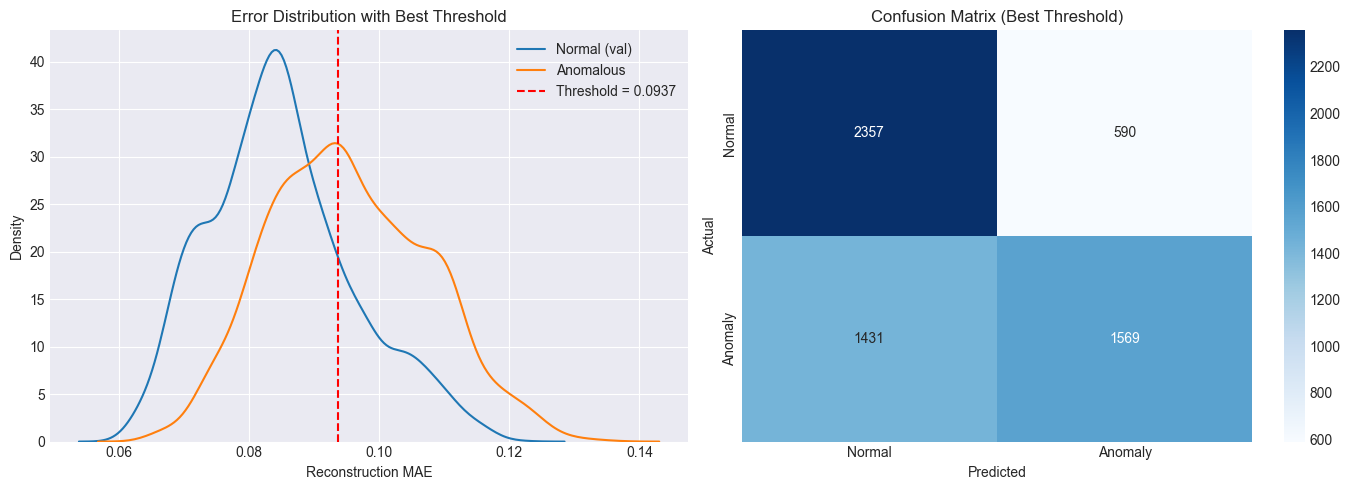

Saved to ../results/final_evaluation.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reconstruction error distributions with threshold line
ax1 = axes[0]
sns.kdeplot(val_mae, label='Normal (val)', ax=ax1)
sns.kdeplot(anomaly_mae, label='Anomalous', ax=ax1)
ax1.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold = {best_threshold:.4f}')
ax1.set_xlabel('Reconstruction MAE')
ax1.set_ylabel('Density')
ax1.set_title('Error Distribution with Best Threshold')
ax1.legend()

# Confusion matrix heatmap
ax2 = axes[1]
cm = confusion_matrix(y_true, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (Best Threshold)')

plt.tight_layout()
plt.savefig('../results/final_evaluation.png', dpi=150)
plt.show()
print("Saved to ../results/final_evaluation.png")

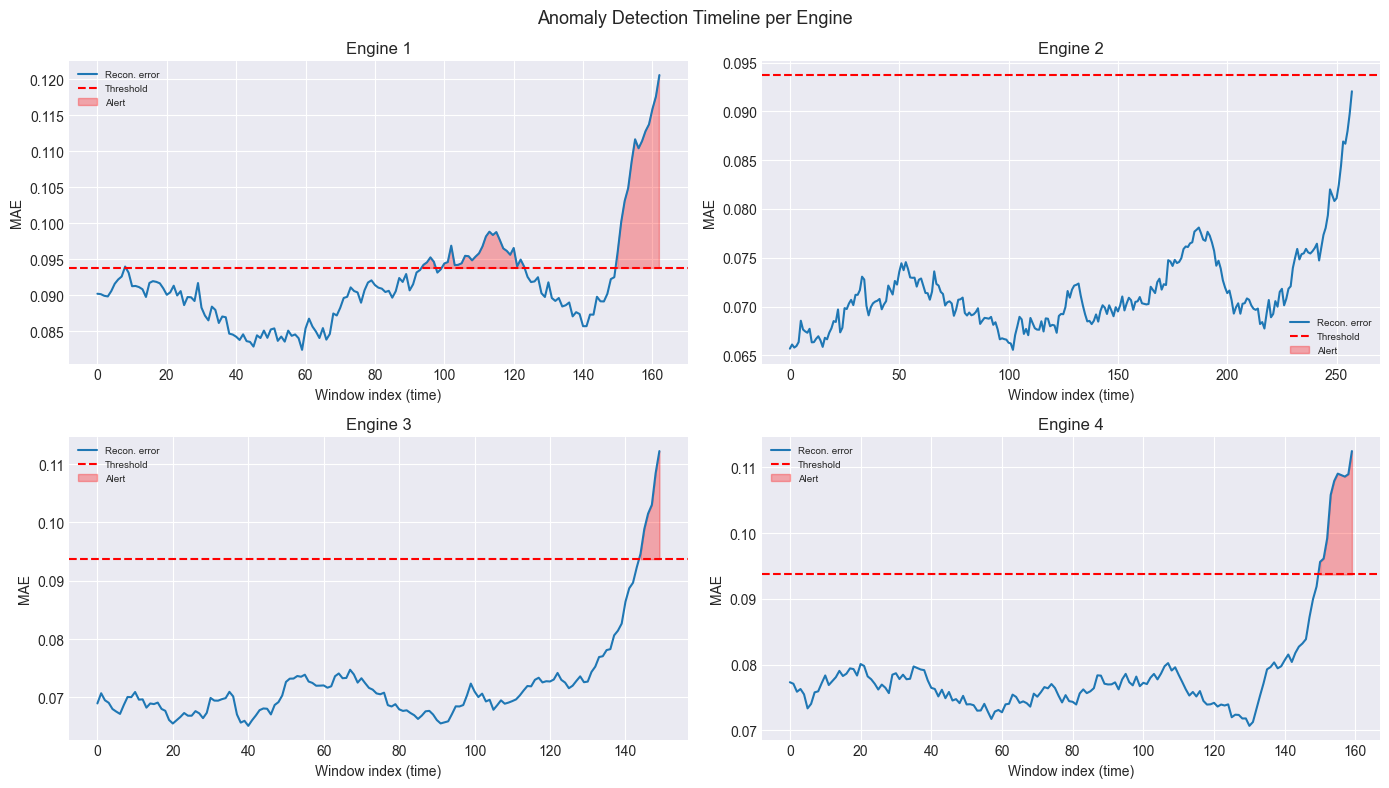

Saved to ../results/engine_timelines.png


In [ ]:
## Per-engine anomaly timeline
#Reconstruct scores over the full dataset to visualize per-engine alert progression

X_all_pred = autoencoder.predict(X, verbose=0)
all_mae = np.mean(np.abs(X_all_pred - X), axis=(1, 2))

# Show representative engines
sample_engines = np.unique(engine_ids)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, eng in zip(axes.flat, sample_engines):
    mask = engine_ids == eng
    ax.plot(all_mae[mask], label='Recon. error')
    ax.axhline(best_threshold, color='red', linestyle='--', label='Threshold')
    ax.fill_between(range(mask.sum()), best_threshold, all_mae[mask],
                    where=(all_mae[mask] > best_threshold), alpha=0.3, color='red', label='Alert')
    ax.set_title(f'Engine {int(eng)}')
    ax.set_xlabel('Window index (time)')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=7)

plt.suptitle('Anomaly Detection Timeline per Engine', fontsize=13)
plt.tight_layout()
plt.savefig('../results/engine_timelines.png', dpi=150)
plt.show()
print("Saved to ../results/engine_timelines.png")

In [19]:
os.makedirs('../models', exist_ok=True)
autoencoder.save('../models/lstm_autoencoder.keras')
print("Model saved to ../models/lstm_autoencoder.keras")

Model saved to ../models/lstm_autoencoder.keras


## Summary

| Item | Value |
|---|---|
| Architecture | LSTM Autoencoder (64-unit encoder/decoder) |
| Training windows | 11,784 normal windows |
| Val MAE (normal) | ~0.0850 |
| Anomaly MAE | ~0.0953 |
| Best threshold | ~0.0937 (80th percentile) |
| Anomaly recall | ~52% |
| Anomaly F1 | ~0.61 |

**Artifacts saved:**
- `../models/lstm_autoencoder.keras` — trained model
- `../results/anomaly_threshold.txt` — best threshold value
- `../results/final_evaluation.png` — error distributions + confusion matrix
- `../results/engine_timelines.png` — per-engine alert timelines

**Next:** `04_evaluation.ipynb` — ROC/PR curves, RUL correlation, and deployment prep.